In [2]:
import numpy as np
import pandas as pd

In [17]:
df = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQtBXo5cBnDsM2fmfHPm6u72KGUS5FjPHNGMxOfYjA9-CAhmnRpwkIw_rOR3sANJIToiUU__6fbBvig/pub?gid=572763137&single=true&output=csv")

In [18]:
df.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [19]:
df.drop(columns=['Time'], inplace=True)

In [28]:
df.isnull().sum()

0            0
1            0
2            0
3            0
4            0
            ..
586          1
587          1
588          1
589          1
Pass/Fail    0
Length: 591, dtype: int64

In [23]:
df.fillna(method='ffill', inplace=True)

C:\Users\cccc\AppData\Local\Temp\ipykernel_21260\3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [29]:
df.fillna(method='bfill', inplace=True)

C:\Users\cccc\AppData\Local\Temp\ipykernel_21260\3314729575.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


In [30]:
df.shape

(1567, 591)

In [31]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


X = df.drop('Pass/Fail', axis=1)
y = df['Pass/Fail']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
print(X_train.shape)
print(X_test.shape)

(1253, 590)
(314, 590)


In [33]:
log_reg = LogisticRegression(max_iter=1000)  
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", accuracy)

Test accuracy: 0.9076433121019108


D:\Users\cccc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 1. Removing Duplicates

In [34]:
def get_duplicate_columns(df):
    
    duplicate_columns = {}
    seen_columns = {}

    for column in df.columns:
        current_column = df[column]

        # Convert column data to bytes
        try:
            current_column_hash = current_column.values.tobytes()
        except AttributeError:
            current_column_hash = current_column.to_string().encode()

        if current_column_hash in seen_columns:
            if seen_columns[current_column_hash] in duplicate_columns:
                duplicate_columns[seen_columns[current_column_hash]].append(column)
            else:
                duplicate_columns[seen_columns[current_column_hash]] = [column]
        else:
            seen_columns[current_column_hash] = column

    return duplicate_columns

In [35]:
duplicate_columns = get_duplicate_columns(X_train)

In [36]:
duplicate_columns

{'13': ['52',
  '97',
  '141',
  '149',
  '178',
  '179',
  '186',
  '189',
  '190',
  '191',
  '192',
  '193',
  '194',
  '226',
  '229',
  '230',
  '231',
  '232',
  '233',
  '234',
  '235',
  '236',
  '237',
  '240',
  '241',
  '242',
  '243',
  '256',
  '257',
  '258',
  '259',
  '260',
  '261',
  '262',
  '263',
  '264',
  '265',
  '266',
  '276',
  '284',
  '313',
  '314',
  '315',
  '322',
  '325',
  '326',
  '327',
  '328',
  '329',
  '330',
  '364',
  '369',
  '370',
  '371',
  '372',
  '373',
  '374',
  '375',
  '378',
  '379',
  '380',
  '381',
  '394',
  '395',
  '396',
  '397',
  '398',
  '399',
  '400',
  '401',
  '402',
  '403',
  '404',
  '414',
  '422',
  '449',
  '450',
  '451',
  '458',
  '461',
  '462',
  '463',
  '464',
  '465',
  '466',
  '481',
  '498',
  '501',
  '502',
  '503',
  '504',
  '505',
  '506',
  '507',
  '508',
  '509',
  '512',
  '513',
  '514',
  '515',
  '528',
  '529',
  '530',
  '531',
  '532',
  '533',
  '534',
  '535',
  '536',
  '537',
  '538

In [37]:
for one_list in duplicate_columns.values():
    X_train.drop(columns=one_list,inplace=True)
    X_test.drop(columns=one_list,inplace=True)

In [38]:
print(X_train.shape)
print(X_test.shape)

(1253, 474)
(314, 474)


# Variance Threshold

In [39]:
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.05)

In [40]:
sel.fit(X_train)

VarianceThreshold(threshold=0.05)

In [42]:
sum(sel.get_support())

np.int64(286)

In [43]:
columns = X_train.columns[sel.get_support()]

In [44]:
columns

Index(['0', '1', '2', '3', '4', '6', '12', '14', '15', '16',
       ...
       '569', '570', '571', '572', '573', '574', '576', '577', '581', '585'],
      dtype='object', length=286)

In [45]:
X_train = sel.transform(X_train)
X_test = sel.transform(X_test)

X_train = pd.DataFrame(X_train, columns=columns)
X_test = pd.DataFrame(X_test, columns=columns)

In [46]:
print(X_train.shape)
print(X_test.shape)

(1253, 286)
(314, 286)


# 3. Correaltion

In [47]:
import seaborn as sns

<Axes: >

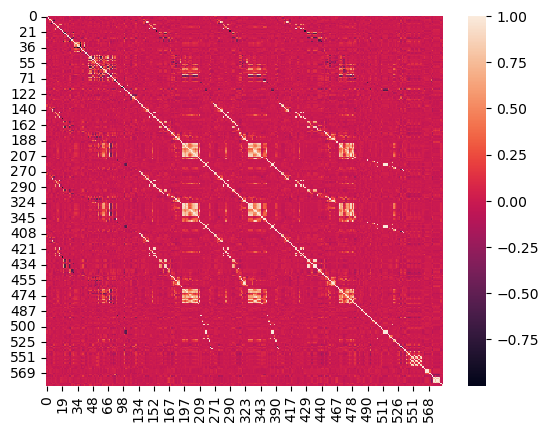

In [48]:
sns.heatmap(X_train.corr())

In [49]:
corr_matrix = X_train.corr()

In [50]:
columns = corr_matrix.columns

# Create an empty list to keep track of columns to drop
columns_to_drop = []

# Loop over the columns
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        # Access the cell of the DataFrame
        if corr_matrix.loc[columns[i], columns[j]] > 0.95:
            columns_to_drop.append(columns[j])

print(len(columns_to_drop))

158


In [51]:
columns_to_drop = set(columns_to_drop)

In [52]:
len(columns_to_drop)

93

In [53]:
X_train.drop(columns = columns_to_drop, axis = 1, inplace=True)
X_test.drop(columns = columns_to_drop, axis = 1, inplace=True)

In [54]:
print(X_train.shape)
print(X_test.shape)

(1253, 193)
(314, 193)


In [55]:
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest


sel = SelectKBest(f_classif, k=100).fit(X_train, y_train)

# display selected feature names
X_train.columns[sel.get_support()]

Index(['0', '14', '19', '21', '22', '23', '27', '28', '31', '32', '33', '37',
       '38', '40', '46', '59', '61', '62', '63', '64', '65', '66', '67', '68',
       '70', '90', '110', '111', '115', '117', '122', '125', '126', '128',
       '129', '133', '134', '137', '138', '159', '160', '164', '180', '181',
       '182', '183', '188', '195', '196', '197', '198', '199', '200', '201',
       '203', '204', '205', '207', '218', '225', '250', '273', '316', '336',
       '337', '356', '417', '418', '423', '426', '430', '431', '432', '433',
       '434', '439', '440', '460', '468', '471', '476', '483', '484', '485',
       '488', '492', '493', '494', '510', '511', '519', '521', '545', '546',
       '547', '549', '550', '551', '561', '573'],
      dtype='object')

In [56]:
columns = X_train.columns[sel.get_support()]

In [57]:
X_train = sel.transform(X_train)
X_test = sel.transform(X_test)

X_train = pd.DataFrame(X_train, columns=columns)
X_test = pd.DataFrame(X_test, columns=columns)

In [58]:
print(X_train.shape)
print(X_test.shape)

(1253, 100)
(314, 100)


# Model Training After Feature Selection

In [59]:
log_reg = LogisticRegression(max_iter=1000) 
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", accuracy)

Test accuracy: 0.9076433121019108


D:\Users\cccc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 5. Chi Square

In [60]:
df = pd.read_csv('car_evaluation.csv')

In [61]:
df.head()

,Unnamed: 0,buying,maint,doors,persons,lug_boot,safety,class
0,0,vhigh,vhigh,2,2,small,low,unacc
1,1,vhigh,vhigh,2,2,small,med,unacc
2,2,vhigh,vhigh,2,2,small,high,unacc
3,3,vhigh,vhigh,2,2,med,low,unacc
4,4,vhigh,vhigh,2,2,med,med,unacc


In [65]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [66]:
ct = pd.crosstab(df['buying'],df['class'],margins=True)
ct

class,acc,good,unacc,vgood,All
buying,,,,,
high,108,0,324,0,432
low,89,46,258,39,432
med,115,23,268,26,432
vhigh,72,0,360,0,432
All,384,69,1210,65,1728


In [69]:
from scipy.stats import chi2_contingency
chi2_contingency(ct)

Chi2ContingencyResult(statistic=np.float64(189.2430096418733), pvalue=np.float64(1.1719086270572124e-31), dof=16, expected_freq=array([[  96.  ,   17.25,  302.5 ,   16.25,  432.  ],
       [  96.  ,   17.25,  302.5 ,   16.25,  432.  ],
       [  96.  ,   17.25,  302.5 ,   16.25,  432.  ],
       [  96.  ,   17.25,  302.5 ,   16.25,  432.  ],
       [ 384.  ,   69.  , 1210.  ,   65.  , 1728.  ]]))

In [70]:
score = []

for feature in df.columns[:-1]:
    
    # create contingency table
    ct = pd.crosstab(df['class'], df[feature])
    
    # chi_test
    p_value = chi2_contingency(ct)[1]
    score.append(p_value)

<Axes: >

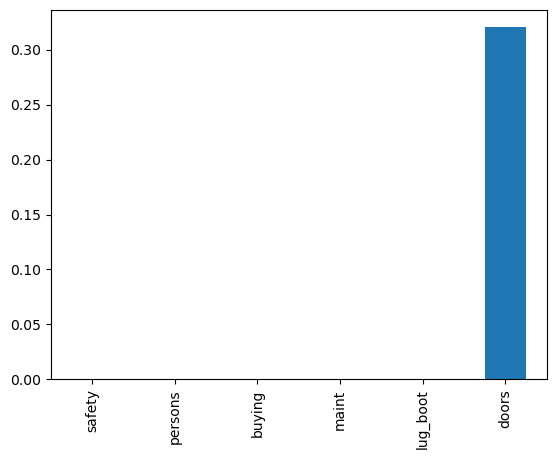

In [72]:
pd.Series(score, index=df.columns[:-1]).sort_values(ascending=True).plot(kind='bar')

### Using Sklearn

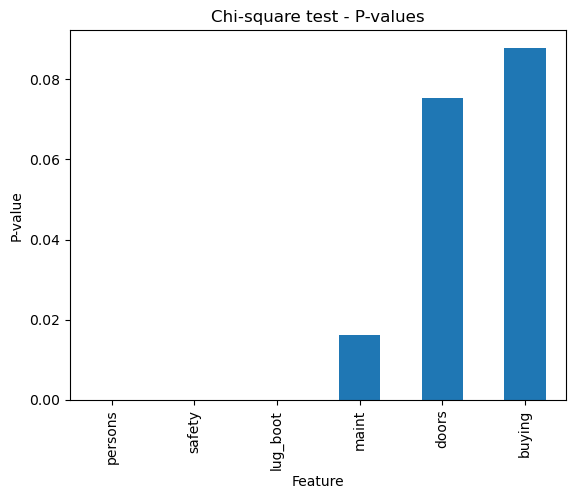

In [73]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
import matplotlib.pyplot as plt

# assuming titanic is your DataFrame and 'Survived' is the target column

# Encode categorical variables
le = LabelEncoder()
df_encoded = df.apply(le.fit_transform)

X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

# Calculate chi-squared stats
chi_scores = chi2(X, y)

# chi_scores[1] are the p-values of each feature.
p_values = pd.Series(chi_scores[1], index = X.columns)
p_values.sort_values(inplace = True)

# Plotting the p-values
p_values.plot.bar()

plt.title('Chi-square test - P-values')
plt.xlabel('Feature')
plt.ylabel('P-value')

plt.show()

# 6. Mutual info

In [74]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris
import pandas as pd

# Load iris dataset
iris = load_iris()
X = iris['data']
y = iris['target']

# Compute mutual information
mi = mutual_info_classif(X, y)

# Print mutual information
for i, mi_value in enumerate(mi):
    print(f"Feature {i}: Mutual Information = {mi_value}")


Feature 0: Mutual Information = 0.4707838694846289
Feature 1: Mutual Information = 0.22078764205637236
Feature 2: Mutual Information = 0.9912325474155281
Feature 3: Mutual Information = 0.9927231934015177


In [75]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.datasets import load_iris

# Load iris dataset
iris = load_iris()
X = iris['data']
y = iris['target']

# Create SelectKBest feature selector
selector = SelectKBest(mutual_info_classif, k=2)

# Fit and transform
X_new = selector.fit_transform(X, y)

# Get columns to keep and create new dataframe with those only
cols = selector.get_support(indices=True)

print(iris.feature_names)
print(cols)


['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[2 3]
